## Primero importaré pandas y exportaré la base de datos

In [2]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv', sep=';' )

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## Como está separado por punto y coma, se volvió a cargar la base de datos.

## Tenemos una lista de 1599 vinos y tenemos que clasificar la calidad de los vinos, por lo que utilizaremos la columna QUALITY



In [3]:
df.quality.unique()

array([5, 6, 7, 4, 8, 3])

## Agregaremos una columna objetivo para asignar un valor a la calidad del vino

In [5]:
df['objetivo'] = df['quality'].map({3:0, 4:0, 5:1, 6:1, 7:2, 8:2})
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,objetivo
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1


## Ahora procedemos a realizar el EDA

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  objetivo              1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,objetivo
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,1.096310
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.407354
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,1.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,1.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,2.000000


## Ahora tengo que ver la correlación con la variable objetivo, nombrada de la misma manera OBJETIVO

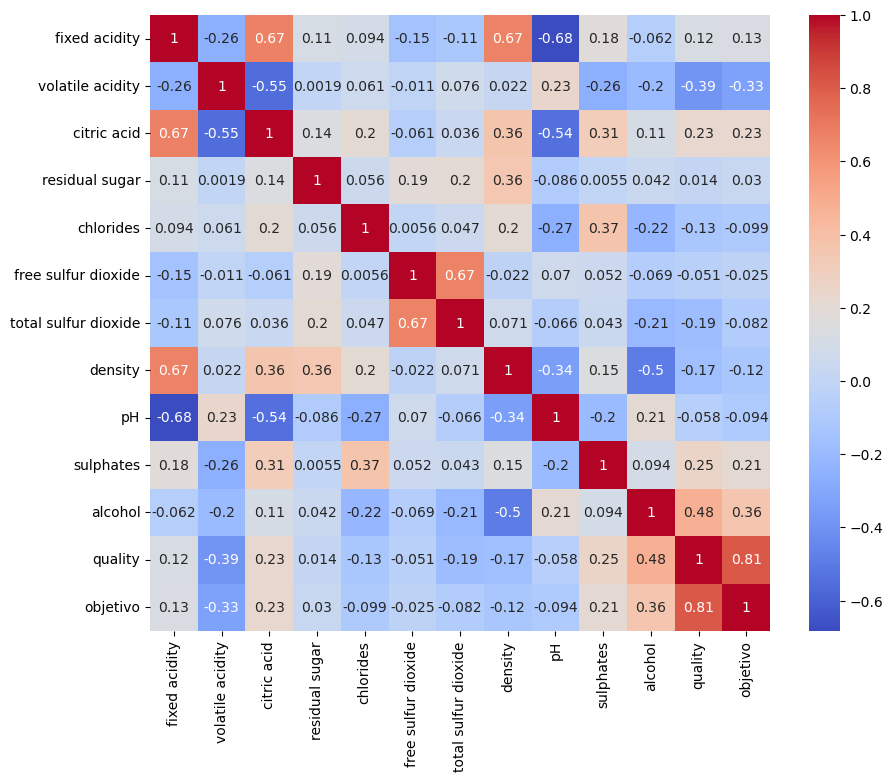

In [9]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## El análisis de correlación muestra que las variables más influyentes en la calidad del vino son ALCOHOL, SULFATOS y ÁCIDO CÍTRICO. Por otro lado, la ACIDEZ VOLÁTIL presenta una correlación negativa significativa, indicando que mayores niveles de esta variable están asociados con menor calidad. Asimismo, se identificaron relaciones entre variables independientes, lo que sugiere la presencia de multicolinealidad en el dataset.

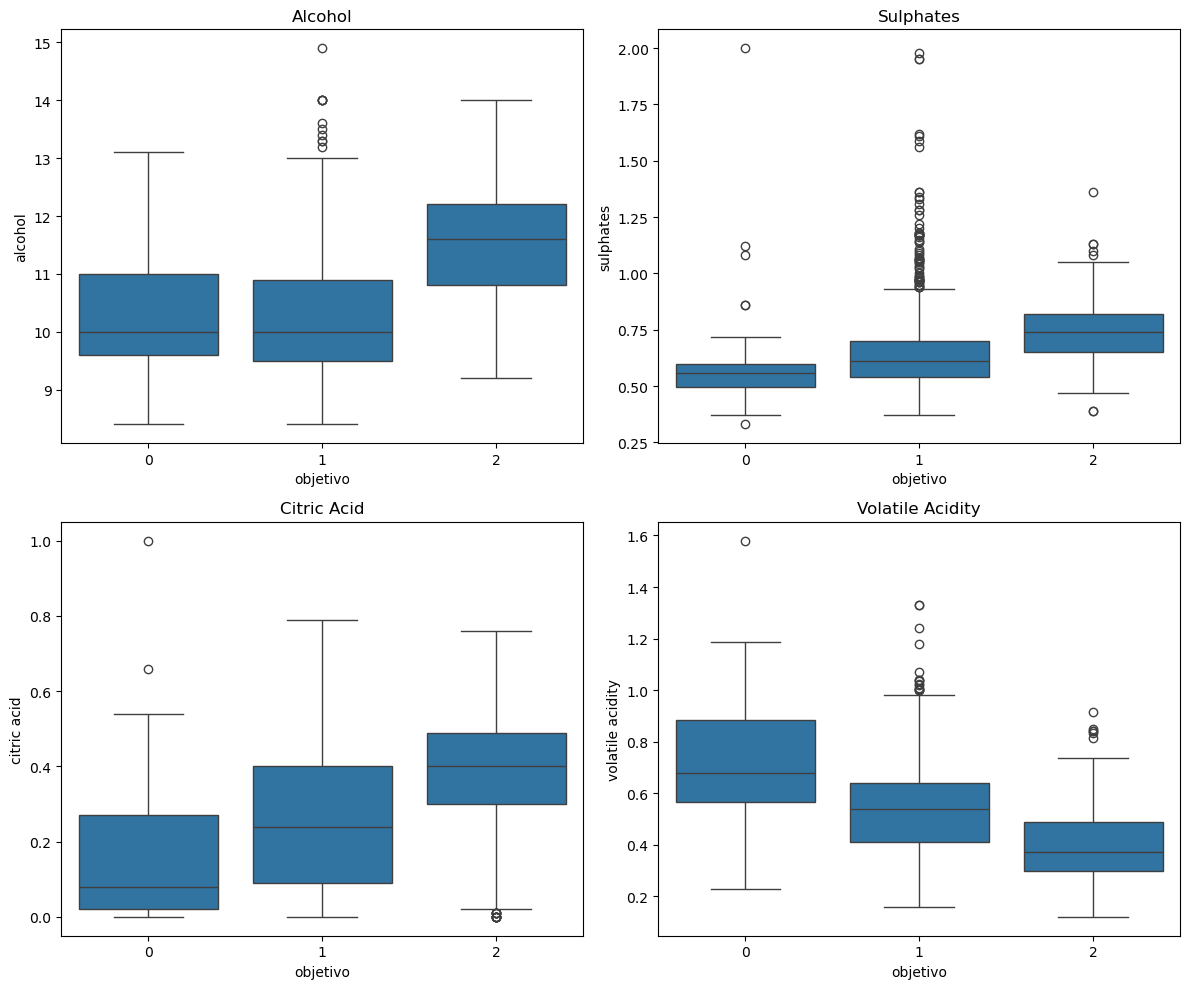

In [13]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(x='objetivo', y='alcohol', data=df)
plt.title("Alcohol")

plt.subplot(2,2,2)
sns.boxplot(x='objetivo', y='sulphates', data=df)
plt.title("Sulphates")

plt.subplot(2,2,3)
sns.boxplot(x='objetivo', y='citric acid', data=df)
plt.title("Citric Acid")

plt.subplot(2,2,4)
sns.boxplot(x='objetivo', y='volatile acidity', data=df)
plt.title("Volatile Acidity")

plt.tight_layout()
plt.show()

## Aquí confirmamos que:

## En conjunto muestra que variables como el alcohol y los sulphates influyen positivamente en la calidad del vino, mientras que la acidez volátil tiene un impacto negativo significativo. Estas relaciones confirman los hallazgos observados en el análisis de correlación y destacan las variables más relevantes para el desarrollo del modelo predictivo.

## Ahora vamos a detectar la presencia de outliers.

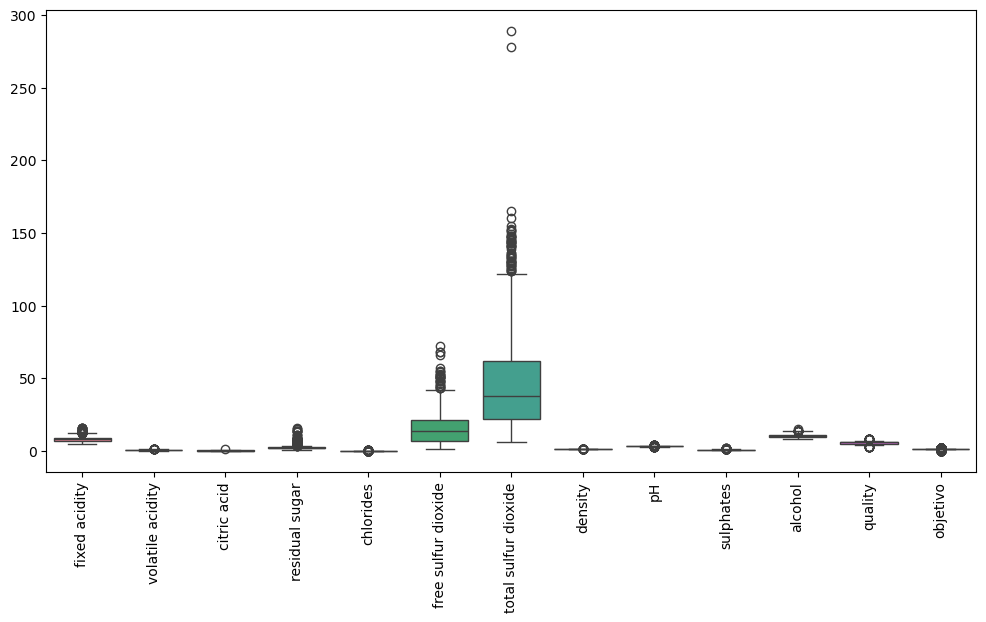

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Con esto se idintificó:

## La presencia de múltiples valores atípicos en variables como total sulfur dioxide, free sulfur dioxide, residual sugar y chlorides. Asimismo, se observa una diferencia considerable en las escalas de las variables, destacando que algunas presentan rangos mucho más amplios que otras.

## Estos hallazgos indican la necesidad de aplicar técnicas de escalado y considerar el tratamiento de outliers antes del modelado.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['quality', 'objetivo'])
y = df['objetivo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Graficado se vería así:

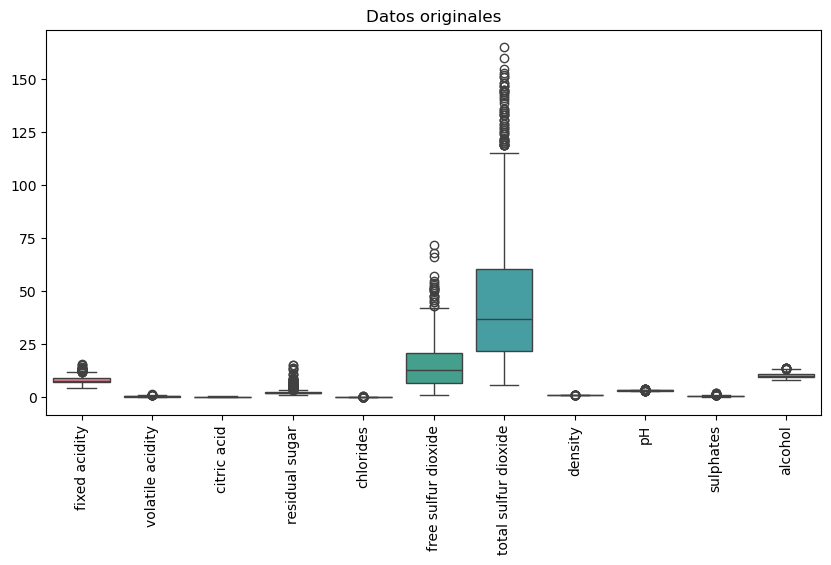

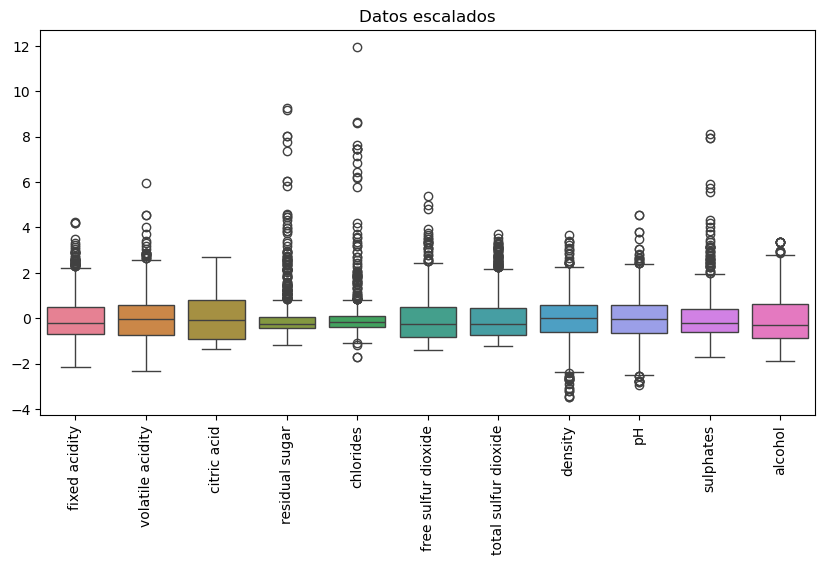

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=X_train)
plt.title("Datos originales")
plt.xticks(rotation=90)
plt.show()

X_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

plt.figure(figsize=(10,5))
sns.boxplot(data=X_scaled_df)
plt.title("Datos escalados")
plt.xticks(rotation=90)
plt.show()

## Se normalizaron los datos para que ninguna variable tenga más peso que otra en el modelo. Por lo que ahora empezaremos el MODELO

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['quality', 'objetivo'], axis =1)
y = df.objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9
...,...,...,...,...,...,...,...,...,...,...,...
1130,9.1,0.600,0.00,1.9,0.058,5.0,10.0,0.99770,3.18,0.63,10.4
1294,8.2,0.635,0.10,2.1,0.073,25.0,60.0,0.99638,3.29,0.75,10.9
860,7.2,0.620,0.06,2.7,0.077,15.0,85.0,0.99746,3.51,0.54,9.5
1459,7.9,0.200,0.35,1.7,0.054,7.0,15.0,0.99458,3.32,0.80,11.9


## Obtenemos sólo características e identificadores saltados, los cuales no se encuentran en la misma escala

In [24]:
from sklearn.preprocessing import MinMaxScaler 

scaler = MinMaxScaler()

X_train_esc = scaler.fit_transform(X_train, y_train)
X_test_esc = scaler.transform(X_test)

X_train_esc = pd.DataFrame(X_train_esc, columns = X_train.columns, index=X_train.index)
X_test_esc = pd.DataFrame(X_test_esc, columns = X_test.columns, index=X_test.index) 

X_train_esc

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,0.362832,0.390411,0.31,0.143836,0.123539,0.328358,0.265018,0.743759,0.582677,0.226994,0.492308
354,0.132743,0.061644,0.40,0.034247,0.090150,0.589552,0.561837,0.082966,0.401575,0.134969,0.538462
342,0.557522,0.184932,0.47,0.061644,0.176962,0.074627,0.028269,0.596916,0.440945,0.233129,0.215385
834,0.371681,0.386986,0.26,0.047945,0.126878,0.223881,0.060071,0.504405,0.456693,0.061350,0.153846
705,0.336283,0.626712,0.15,0.349315,0.101836,0.149254,0.169611,0.655653,0.496063,0.073620,0.230769
...,...,...,...,...,...,...,...,...,...,...,...
1130,0.398230,0.328767,0.00,0.068493,0.076795,0.059701,0.014134,0.560206,0.346457,0.159509,0.307692
1294,0.318584,0.352740,0.10,0.082192,0.101836,0.358209,0.190813,0.463289,0.433071,0.233129,0.384615
860,0.230088,0.342466,0.06,0.123288,0.108514,0.208955,0.279152,0.542584,0.606299,0.104294,0.169231
1459,0.292035,0.054795,0.35,0.054795,0.070117,0.089552,0.031802,0.331131,0.456693,0.263804,0.538462


## Ahora ya tengo mis X de Train escalados en rangos de  0 y 1

## Ahora vamos a continuar con mi modelo

In [25]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

model.fit(X_train_esc, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Procedemos a las predicciones

In [26]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## Aqui no es posible ver de forma completa el rendimiento del modelo y tenemos que encontrarlo

In [29]:
from sklearn.metrics import accuracy_score

accuracy_score (y_test, y_pred)

0.8125

## Nuestro rendimiento es de 81.25% o lo que se podría predecir como regulares y es un buen modelo, ya que nuestro margen de esrror es sólo del 19.75%

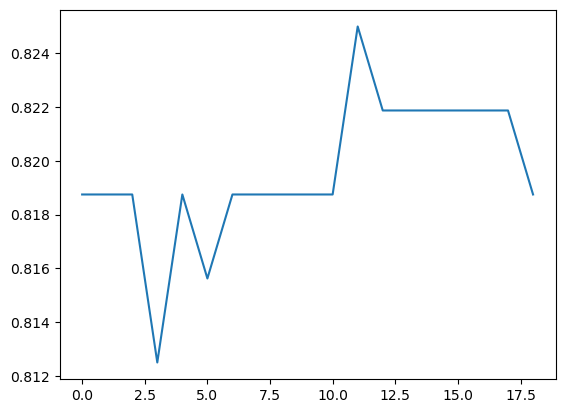

In [33]:
accuracies = []

for k in range(2, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_esc, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

import matplotlib.pyplot as plt

plt.plot(accuracies)
plt.show()

## Se evaluó el rendimiento del modelo KNN variando el número de vecinos (K). Se observó que el mejor desempeño se obtiene con un valor cercano a K=13, alcanzando un accuracy aproximado del 82.5%. Valores pequeños de K generan sobreajuste, mientras que valores grandes tienden a reducir la precisión del modelo.

In [35]:
model = KNeighborsClassifier(n_neighbors=13)

model.fit(X_train_esc, y_train)
y_pred = model.predict(X_test)
accuracy_score (y_test, y_pred)


0.825

## Nuestro rendimiento subió a 82.5% que lo hace mejor; hay que guardar ahora el modelo

In [36]:
from pickle import dump

dump(model, open ("../models/KNN_13.model", "wb"))

## Para rescatar nuestro modelo para usarlo en una función

In [53]:
from pickle import load
import numpy as np

texto = []

def predict_wine_quality(valores):
    model = load(open("../models/KNN_13.model", "rb"))
    valores = np.array(valores)
    valores = scaler.transform(valores.reshape(1, -1))
    calidad = model.predict(valores.reshape(1, -1))
   
    if calidad[0] == 0:
        print("La calidad del vino es baja")
    elif calidad[0] == 1:
        print("La calidad del vino es promedio")
    else:
        print("La calidad del vino es alta")
    return print(texto)

## Ya tenieno nuetra función, procedemos a prdecir nuevamente la lista dada:

In [54]:
predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

La calidad del vino es promedio
[]


f:\ANACONDA\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
f:\ANACONDA\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## CONCLUSIÓN: Se analizaron los datos del vino, se identificaron las variables más importantes, se prepararon los datos y se entrenó un modelo KNN que logra predecir la calidad con una buena precisión del 82% y en donde se encontró que en este viñedo, la calidad del vino es promedio.